In [24]:
import ROOT as r
import numpy as np
import matplotlib.pyplot as plt

In [25]:
!pwd

/home/samuel/Work/Muography_Denoising


In [26]:
!ls

MuonGeneration
MuonGeneration-build
POCA_points.root
POCA_points.root.root
README.md
RESULTADOS_test_modelo0UNET.png
_Lpx128_Lpy128_Lpz128_npx128_npy128_npz128_zTop54_zBot-54_spacing5_ratio1_FontX16_FontY16_matiron_wordNMUO_stroke2.json
context.txt
correlated_dataset.root
cry
ejemplo_instancia_UNET_04mayo.npy
ejemplo_instancia_UNET_04mayo_channels.png
guide_slurm.md
pipeline_debugging.ipynb
poca_and_theta.npy
poca_projection.npy
postPOCA_04mayo.root
prueba_04mayo.root
setup.sh
visualizaciones_5ch_test


In [27]:
file = r.TFile("/home/samuel/Work/Muography_Denoising/prueba_04mayo.root")
tree = file.Get("hits")
tree.Print()

******************************************************************************
*Tree    :hits      : The hits                                               *
*Entries : 18235239 : Total =      3435304026 bytes  File  Size = 1998589885 *
*        :          : Tree compression factor =   1.72                       *
******************************************************************************
*Br    0 :eventNumber : Int_t hits                                           *
*Entries : 18235239 : Total  Size=  146133098 bytes  File Size  =   36174241 *
*Baskets :     2279 : Basket Size=      32000 bytes  Compression=   4.04     *
*............................................................................*
*Br    1 :det       : Int_t hits                                             *
*Entries : 18235239 : Total  Size=  146114826 bytes  File Size  =   29809110 *
*Baskets :     2279 : Basket Size=      32000 bytes  Compression=   4.90     *
*...................................................

In [28]:
# !python3 ~/Work/Muography_Denoising/MuonGeneration/dataAnalysis/makeHLTuple.py --input /home/samuel/Work/Muography_Denoising/MuonGeneration/dataAnalysis/makeHLTuple.py --input ./prueba_04mayo.root --conf _Lpx128_Lpy128_Lpz128_npx128_npy128_npz128_zTop54_zBot-54_spacing5_ratio1_FontX16_FontY16_matiron_wordNMUO_stroke2.json --output correlated_dataset.root

In [29]:
!python3 /home/samuel/Work/Muography_Denoising/MuonGeneration/dataAnalysis/POCA1.py --input correlated_dataset.root --output POCA_points --Lpx 128 --Lpy 128 --Lpz 128 --npx 128 --npy 128 --npz 128 --dimension "2D"

Iniciando POCA (python entered)
basic libraries imported
[CORRECT] ----- ALL LIBRARIES successfully imported
Volume: [-64.0,64.0] x [-64.0,64.0] x [-64.0,64.0] cm
Grid:   128 x 128 x 128 voxels
Voxel size: 1.000 x 1.000 x 1.000 cm
[INFO] ----- Current: Voxelization of POCA points...
Info in <[ROOT.RDF] Info /home/conda/feedstock_root/build_artifacts/bld/rattler-build_root_base_1773350576/work/build-dir/include/ROOT/RDF/RInterface.hxx:1363 in auto ROOT::RDF::RInterface<ROOT::Detail::RDF::RJittedFilter>::Snapshot(std::string_view, std::string_view, const ColumnNames_t &, const RSnapshotOptions &)::(anonymous class)::operator()() const [Proxied = ROOT::Detail::RDF::RJittedFilter, DataSource = void]>: 
	In ROOT 6.38, the default compression settings of Snapshot have been changed from 101 (ZLIB with compression level 1, the TTree default) to 505 (ZSTD with compression level 5). This change may result in smaller Snapshot output dataset size by default. In order to suppress this message, set 

In [30]:
!ls


MuonGeneration
MuonGeneration-build
POCA_points.root
POCA_points.root.root
README.md
RESULTADOS_test_modelo0UNET.png
_Lpx128_Lpy128_Lpz128_npx128_npy128_npz128_zTop54_zBot-54_spacing5_ratio1_FontX16_FontY16_matiron_wordNMUO_stroke2.json
context.txt
correlated_dataset.root
cry
ejemplo_instancia_UNET_04mayo.npy
ejemplo_instancia_UNET_04mayo_channels.png
guide_slurm.md
pipeline_debugging.ipynb
poca_and_theta.npy
poca_projection.npy
postPOCA_04mayo.root
prueba_04mayo.root
setup.sh
visualizaciones_5ch_test


In [31]:
import ROOT
df = ROOT.RDataFrame("events", "POCA_points.root")
res = df.AsNumpy(columns=["is_parallel"])

print(res["is_parallel"].dtype)
print(np.unique(res["is_parallel"], return_counts=True))


bool
(ndarray([False,  True]), array([ 1508, 70133]))


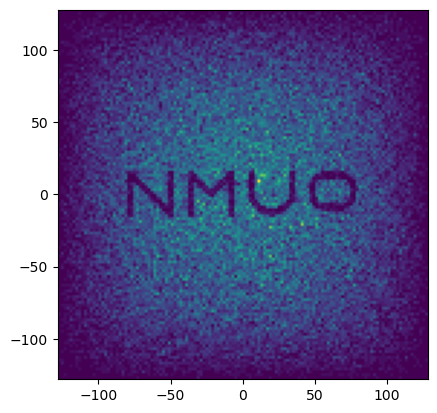

In [34]:
image_projected = dict_["counts_2d"]
plt.imshow(image_projected, origin='lower', extent=[-128, 128, -128, 128], cmap='viridis')

In [35]:
# Con POCA1_copy (coordenadas brutas)
data = np.load("poca_and_theta.npy", allow_pickle=True).item()
print("N eventos copy:", len(data["poca_x"]))

# Con POCA1 (voxelización)
dict_ = np.load("poca_projection.npy", allow_pickle=True).item()
print("N eventos POCA1:", dict_["counts_2d"].sum())

N eventos copy: 1508
N eventos POCA1: 71641.0


In [36]:
print("Eventos con NaN:", np.sum(np.isnan(data["poca_x"])))
print("Fuera de volumen:", np.sum(np.abs(data["poca_x"]) > 64))

Eventos con NaN: 0
Fuera de volumen: 0


In [37]:
dict_ = np.load("poca_projection.npy", allow_pickle=True).item()
print("counts_2d sum:", dict_["counts_2d"].sum())
print("counts_2d max:", dict_["counts_2d"].max())
print("counts_2d shape:", dict_["counts_2d"].shape)


counts_2d sum: 71641.0
counts_2d max: 26.0
counts_2d shape: (128, 128, 1)


In [38]:
data = np.load("poca_and_theta.npy", allow_pickle=True).item()
print("poca_z range:", data["poca_z"].min(), data["poca_z"].max())
print("poca_x range:", data["poca_x"].min(), data["poca_x"].max())
print("poca_y range:", data["poca_y"].min(), data["poca_y"].max())


poca_z range: -63.89967346191406 63.92776870727539
poca_x range: -63.580177307128906 62.72747039794922
poca_y range: -63.01277160644531 63.608089447021484


In [40]:
!ls -lh correlated_dataset.root
# y si tienes la ruta completa también:
!ls -lh /home/samuel/Work/Muography_Denoising/correlated_dataset.root


-rw-r--r-- 1 samuel samuel 11M May  4 12:25 correlated_dataset.root
-rw-r--r-- 1 samuel samuel 11M May  4 12:25 /home/samuel/Work/Muography_Denoising/correlated_dataset.root


In [42]:
import ROOT

f = ROOT.TFile("correlated_dataset.root")
t = f.Get("events")
print("N entries:", t.GetEntries())

N entries: 292858


In [43]:
import ROOT
df = ROOT.RDataFrame("events", "correlated_dataset.root")
print("Total:", df.Count().GetValue())

df2 = df.Define("dx", "x2-x1").Define("dy","y2-y1").Define("dz","z2-z1") \
        .Define("A","dx*vx1+dy*vy1+dz*vz1") \
        .Define("B","vx2*vx1+vy2*vy1+vz2*vz1") \
        .Define("C","vx1*vx1+vy1*vy1+vz1*vz1") \
        .Define("D","dx*vx2+dy*vy2+dz*vz2") \
        .Define("E","vx2*vx2+vy2*vy2+vz2*vz2") \
        .Define("t1","(A*E-B*D)/(C*E-B*B)") \
        .Define("t2","-(B*A-C*D)/(B*B-C*E)") \
        .Define("poca_x","((x1+t1*vx1)+(x2+t2*vx2))/2.0") \
        .Define("poca_y","((y1+t1*vy1)+(y2+t2*vy2))/2.0") \
        .Define("poca_z","((z1+t1*vz1)+(z2+t2*vz2))/2.0")

print("Antes del filtro:", df2.Count().GetValue())
df3 = df2.Filter("poca_x >= -64 && poca_x <= 64 && poca_y >= -64 && poca_y <= 64 && poca_z >= -64 && poca_z <= 64")
print("Después del filtro:", df3.Count().GetValue())

# Ver rango de las POCAs ANTES del filtro
res = df2.AsNumpy(columns=["poca_x","poca_y","poca_z"])
print("poca_x range:", res["poca_x"].min(), res["poca_x"].max())
print("poca_y range:", res["poca_y"].min(), res["poca_y"].max())
print("poca_z range:", res["poca_z"].min(), res["poca_z"].max())

Total: 292858
Antes del filtro: 292858
Después del filtro: 1508
poca_x range: nan nan
poca_y range: nan nan
poca_z range: nan nan
